In [1]:
import numpy as np
from numpy import *
import array
import math
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [2]:
# CONSTANTS
# number of arms
ARMS = 10

Initialize the expected reward for each arm.

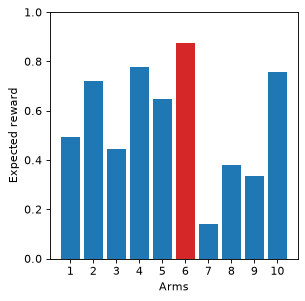

best arm 6


In [3]:
# expected reward for each of the arms (random)
exp_r = np.random.uniform(0, 1, ARMS)
best_arm = np.argmax(exp_r)

plt.figure(figsize=(4, 4), dpi=80)

y_pos = np.arange(len(exp_r)) + 1
plt.bar(y_pos, exp_r, align='center', color=[ "tab:red" if i==best_arm else "tab:blue" for i in range(len(exp_r)) ])
plt.xticks(y_pos)
plt.ylabel('Expected reward')
plt.xlabel('Arms')
plt.ylim(0.,1.)
plt.show()

print("best arm", best_arm + 1)


In [4]:
def avg_reward(exp_r, n, HALF_SIZE):
    '''
    Compute the average reward playing each arm A for n rounds
    exp_r: list of expected reward for each arm
    T: number of rounds
    HALF_SIZE: max reward variation
    '''
    
    avg_r = np.zeros(exp_r.shape) 
    
    for r in range(n):
        avg_r += np.random.uniform(exp_r - HALF_SIZE, exp_r + HALF_SIZE) 
        #print(avg_r,'\n','\n')
    return avg_r/n

In [5]:
# testing that the mean of the n numbers between a and b is (a+b)/2
sum = 0 
for i in range(10000):
    number = np.random.uniform(50,100)
    sum += number

avg = np.mean(sum)
avg

np.float64(749649.4383373976)

# Experiment 1

Play the same arm 100 and 10,000 times. What do you expect to obtain?
the more we play the avrage reward we get get closer to exp_r of that arm; for example when n was 100 once I got the arm 9 as the best one while 6 was.
                                        
For the LLN's law we know that the regret approaches 

- 0 for the best arm and 
- $T \Delta_a$, the gap $\Delta_a$ between the best arm and the selected arm $a$ times the number of rounds $T$ otherwise

100 rounds
best arm 6


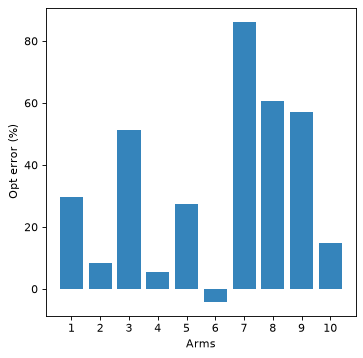

In [6]:
# experiment 1: What happens if you play the same arm
ROUNDS = 100
HALF_SIZE = 1.
prc = np.zeros(ARMS)

avg_r = avg_reward(exp_r, ROUNDS, HALF_SIZE)
print (ROUNDS, "rounds")
best_arm_avg = np.argmax(avg_r)
print ("best arm", best_arm_avg + 1)

# optimisation error (percentage)
for a in range (0, ARMS):
    prc[a] = (1 - avg_r[a] / exp_r[best_arm]) * 100

    
plt.figure(figsize=(5, 5), dpi=80)
y_pos = np.arange(len(prc)) + 1
plt.bar(y_pos, prc, align='center', alpha=0.9)
plt.xticks(y_pos)
plt.ylabel('Opt error (%)')
plt.xlabel('Arms')

plt.show()

# Experiment 2: Explore and commit

Play each arm EXP_ROUNDS (number of rounds dedicated to exploration for each arm) and then play the arm with the highest average reward for the remaining rounds (ROUNDS - EXP_ROUNDS * ARMS). Check what happens for different values of EXP_ROUNDS

In [7]:
def compute_gap(optimal_r, emp_best_r, n):
    '''
    Compute gap between the best arm and the selected arm for n rounds
    optimal_r: optimal reward 
    emp_best_r: best empirical reward 
    n: number of rounds played
    '''
    delta = optimal_r * n - emp_best_r
    return delta
    
def optimization_error(exp_r, EXP_ROUNDS, ROUNDS, HALF_SIZE):
    '''
    Explore-Then-Commit strategy
    EXPLORE playing all the arms and finding the best empirical reward
    THEN play that arm leading to the best empirical reward
    
    Parameters.
    exp_r: expected reward
    EXP_ROUNDS: rounds to explore
    ROUNDS: rounds to play
    HALF_SIZE: max reward variation
    '''
    
    # first, explore for EXP_ROUNDS
    avg_r = avg_reward(exp_r, EXP_ROUNDS, HALF_SIZE)
    #print(avg_r)
    # best arm empirically found 
    arm = np.argmax(avg_r) 
    # then commit, play the best arm found for ROUNDS time
    cumul_r = 0.
    for i in range(ROUNDS):
        reward = np.random.uniform(exp_r[arm] - HALF_SIZE, exp_r[arm] + HALF_SIZE) 
        cumul_r += reward
    
    # compute optimization error
    #opt = (exp_r[arm] - (cumul_r/ ROUNDS))# / (ROUNDS)

    opt = compute_gap(exp_r[best_arm],cumul_r, ROUNDS)
    return opt

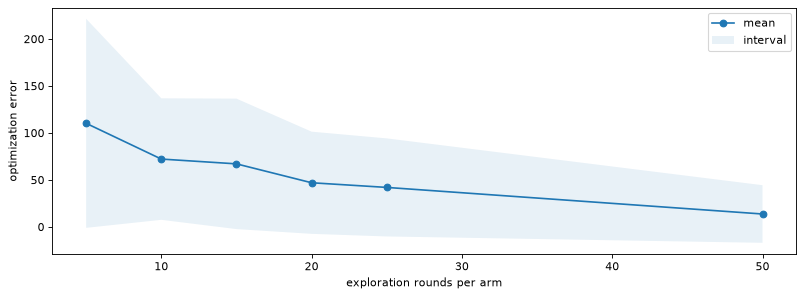

In [8]:
# experiment 2: going greedy (exploitation) after some exploration
ROUNDS = 1000
EXP_ROUNDS_LIST = np.array([5, 10, 15, 20, 25, 50])
# when you are done check what happens when you run 1000 instead of 100 experiments
REPEAT_EXPERIMENTS = 100

opt_list = []
for repreat in range(REPEAT_EXPERIMENTS):
    opt_list.append([optimization_error(exp_r, EXP_ROUNDS, ROUNDS - EXP_ROUNDS * ARMS, HALF_SIZE) for EXP_ROUNDS in EXP_ROUNDS_LIST ])
    
opt_list = np.array(opt_list)
mean_opt_list = np.mean(opt_list, axis=0) # compute the mean wrt to the number of repeats
max_opt_list = np.std(opt_list, axis=0)
min_opt_list = np.std(opt_list, axis=0)


plt.figure(figsize=(12, 4), dpi=80)
plt.plot(EXP_ROUNDS_LIST, mean_opt_list, marker="o", label="mean")
plt.fill_between(EXP_ROUNDS_LIST, mean_opt_list + max_opt_list, mean_opt_list - min_opt_list, label="interval", alpha=0.1)
#plt.plot(EXP_ROUNDS_LIST, (ROUNDS*ARMS)/np.sqrt(EXP_ROUNDS_LIST), color = "red", label="bound")
plt.xlabel("exploration rounds per arm")
plt.ylabel("optimization error")
plt.legend()

# Experiment 3: $\epsilon$-greedy

Initialise the average reward by playing each arm once. Then, proceed by playing the arm with the highest average return with probability $1-\epsilon$ and an arm sampled uniformly at random otherwise. Check what happens for different values of $\epsilon$.

In [9]:

def regret(exp_r, ROUNDS, epsilon, HALF_SIZE):
    '''    
    Parameters.
    exp_r: expected reward
    ROUNDS: rounds to play
    HALF_SIZE: max reward variation
    '''
    
    ARMS = exp_r.size # number of arms
    
    avg_r = np.random.uniform(exp_r - HALF_SIZE, exp_r + HALF_SIZE)
    arm = np.argmax(avg_r)
    times_played = np.ones(ARMS)
    times_played[arm] += 1
    cumul_r = avg_r[arm]
    
    for r in range (1, ROUNDS):
        
        # going random with probability epsilon 
        if np.random.uniform(0, 1) < epsilon:
            arm = np.random.randint(0,ARMS)
            tmp = np.random.uniform(exp_r[arm] - HALF_SIZE, exp_r[arm] + HALF_SIZE)
            
            cumul_r += tmp
            avg_r[arm] += (tmp - avg_r[arm]) / times_played[arm] 
        else :
            tmp = np.random.uniform(exp_r[arm] - HALF_SIZE, exp_r[arm] + HALF_SIZE)
    
            cumul_r += tmp
            avg_r[arm] += (tmp - avg_r[arm]) / times_played[arm] 
        
        # update the best arm empirically found
        arm = np.argmax(avg_r)
        times_played[arm] += 1
    
    # compute optimization error
    best_arm = np.argmax(exp_r) # arm of the optimal policy
    regret = compute_gap(exp_r[best_arm],cumul_r, ROUNDS)
    
    return regret

Text(0, 0.5, 'regret')

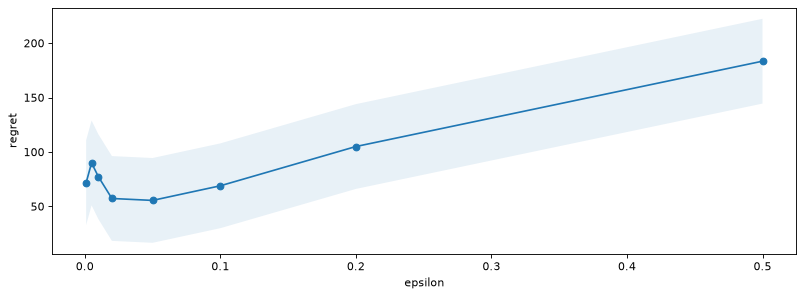

In [10]:
# experiment 3: going epsilon-greedy 
ROUNDS = 1000
EPSILON_LIST = np.array([.001, .005, .01, .02, 0.05, 0.1, 0.2, 0.5]) # probability of choosing a policy at random
# when you are done check what happens when you repeat the experiments 1000 times
REPEAT_EXPERIMENTS = 100

regret_list = []
for repreat in range(REPEAT_EXPERIMENTS):
    regret_list.append([regret(exp_r, ROUNDS, epsilon, HALF_SIZE) for epsilon in EPSILON_LIST ])

# compute the mean wrt to the number of repeats
regret_list = np.array(regret_list)
regret_list = np.mean(regret_list, axis=0) 
std_regret_list = np.std(regret_list, axis=0)

plt.figure(figsize=(12, 4), dpi=80)
plt.plot(EPSILON_LIST, regret_list, marker="o", label="regret")
plt.fill_between(EPSILON_LIST, regret_list + std_regret_list, regret_list - std_regret_list, label="interval", alpha=0.1)
plt.xlabel("epsilon")
plt.ylabel("regret")